In [2]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

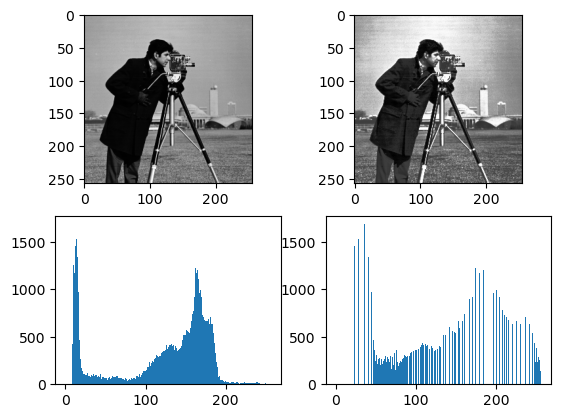

In [8]:
img = cv2.imread(r"C:\Users\soura\Documents\Sem 6 Labs\IPMV\Images\cameraman.tif",0)
plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')

equalized = cv2.equalizeHist(img)
plt.subplot(2,2,2)
plt.imshow(equalized, cmap='gray')

plt.subplot(2,2,3)
plt.hist(img.ravel(), bins=256, range=(0,256))

plt.subplot(2,2,4)
plt.hist(equalized.ravel(), bins=256, range=(0,256))
plt.show()

In [ ]:
img = img.astype(float)
# Knee point
# r1 & r2 are input intensity points
r1, r2 = 70,180
# s1 & s2 are output intensity points
s1, s2 = 30, 220
# Slopes
m1=s1/r1
m2=(s2-s1)/(r2-r1)
m3=(255-s2)/(255-r2)
# Output image
output=np.zeros(img.shape);
output[img <= r1] = m1*img[img<=r1]
output[(img>r1) & (img<=r2)]=s1+m2*img[(img>r1) & (img<=r2)]
output[img>r2]=s2+m3*img[img>r2]
# Convert into uint8
output=np.clip(output,0,255).astype('uint8')
# Display
plt.subplot(1,2,1)
plt.imshow(output,cmap='gray')
plt.subplot(1,2,2)
plt.hist(output.ravel(),256)
plt.show(